# Online Risk Controllers

Demonstrates the Adaptive Conformal Inference (ACI) integral controller and the Conformal PID controller.

In [1]:
import os
os.chdir(r'D:\424_project-main')  # ensure relative paths resolve from project root


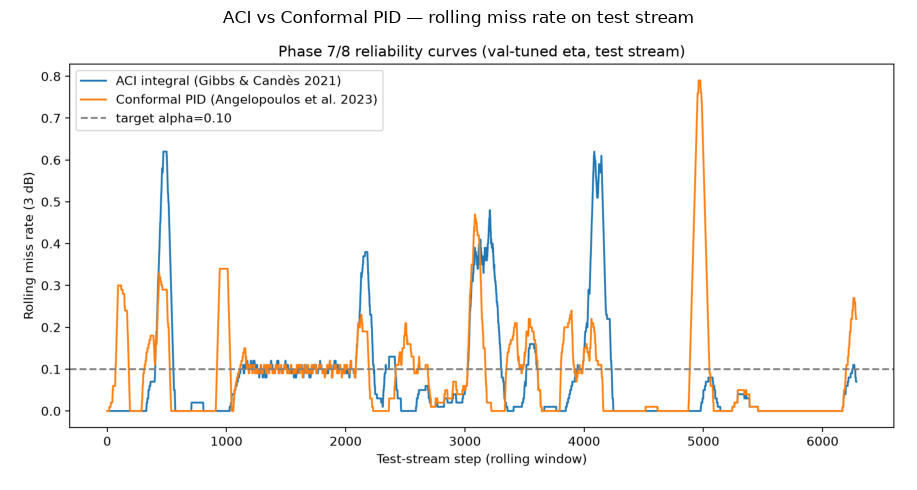

ACI: miss=7.5%  probes=17  search_red=93%
PID: miss=8.6%  probes=49  search_red=81%


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
from src.online_controller import run_online_aci_controller, run_online_pid_controller

# Show reliability curves if available
curves_path = 'results/reliability_curves.png'
if os.path.exists(curves_path):
    import matplotlib.image as mpimg
    img = mpimg.imread(curves_path)
    plt.figure(figsize=(12, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title('ACI vs Conformal PID — rolling miss rate on test stream')
    plt.tight_layout()
    plt.show()
else:
    print('Reliability curves not found — run python -m src.complete_blueprint_steps first.')

# Show telecom utility
import pandas as pd
tel_path = 'results/telecom_utility_table.csv'
if os.path.exists(tel_path):
    tel = pd.read_csv(tel_path)
    aci = tel[tel['method']=='online_aci'].iloc[0]
    pid = tel[tel['method']=='conformal_pid'].iloc[0]
    print(f'ACI: miss={aci["miss_rate"]*100:.1f}%  probes={aci["avg_probes"]:.0f}  search_red={aci["search_reduction"]*100:.0f}%')
    print(f'PID: miss={pid["miss_rate"]*100:.1f}%  probes={pid["avg_probes"]:.0f}  search_red={pid["search_reduction"]*100:.0f}%')
